# Random Forest - Option Price Prediction

References:
- https://www.sciencedirect.com/science/article/pii/S0304405X24001235
- https://thesis.eur.nl/pub/67130/Thesis_MvLent_Final.pdf

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    explained_variance_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 2. Load Data

In [3]:
# Options: secid, date, exdate, cp_flag, strike_price, best_bid, best_offer,
#          volume, impl_volatility, delta, gamma, vega, theta, optionid,
#          forward_price, ticker, index_flag, issuer, exercise_style
options_df = pd.read_csv('options.csv', low_memory=False)

# Stock: PERMNO, HdrCUSIP, Ticker, PERMCO, DlyCalDt, DlyPrc, DlyVol,
#        DlyClose, DlyLow, DlyHigh, DlyBid, DlyAsk, DlyOpen, DlyNumTrd
stock_df = pd.read_csv('stocks.csv', low_memory=False)

print('Options shape:', options_df.shape, '\nColumns:', list(options_df.columns))
print('\nStock shape:', stock_df.shape, '\nColumns:', list(stock_df.columns))

Options shape: (3373875, 19) 
Columns: ['secid', 'date', 'exdate', 'cp_flag', 'strike_price', 'best_bid', 'best_offer', 'volume', 'impl_volatility', 'delta', 'gamma', 'vega', 'theta', 'optionid', 'forward_price', 'ticker', 'index_flag', 'issuer', 'exercise_style']

Stock shape: (1008, 14) 
Columns: ['PERMNO', 'HdrCUSIP', 'Ticker', 'PERMCO', 'DlyCalDt', 'DlyPrc', 'DlyVol', 'DlyClose', 'DlyLow', 'DlyHigh', 'DlyBid', 'DlyAsk', 'DlyOpen', 'DlyNumTrd']


In [4]:
print(options_df.head())
print(stock_df.head())

    secid        date      exdate cp_flag  strike_price  best_bid  best_offer  \
0  101062  2024-08-29  2024-08-30       C        300000     266.9      272.25   
1  101062  2024-08-29  2024-08-30       C        310000     256.9      262.25   
2  101062  2024-08-29  2024-08-30       C        320000     246.9      252.25   
3  101062  2024-08-29  2024-08-30       C        330000     236.9      242.25   
4  101062  2024-08-29  2024-08-30       C        340000     226.9      232.25   

   volume  impl_volatility  delta  gamma  vega  theta   optionid  \
0       0              NaN    NaN    NaN   NaN    NaN  162978660   
1       0              NaN    NaN    NaN   NaN    NaN  162978661   
2       0              NaN    NaN    NaN   NaN    NaN  162978662   
3       0              NaN    NaN    NaN   NaN    NaN  162978663   
4       0              NaN    NaN    NaN   NaN    NaN  162978664   

   forward_price ticker  index_flag     issuer exercise_style  
0            NaN   ADBE           0  ADO

## 3. Preprocessing & Merge

In [5]:
# Standardise ticker & date for merge
options_df['ticker'] = options_df['ticker'].astype(str).str.strip().str.upper()
stock_df['Ticker']   = stock_df['Ticker'].astype(str).str.strip().str.upper()

options_df['date']   = pd.to_datetime(options_df['date'])
options_df['exdate'] = pd.to_datetime(options_df['exdate'])
stock_df['DlyCalDt'] = pd.to_datetime(stock_df['DlyCalDt'])

stock_df.rename(columns={'Ticker': 'ticker', 'DlyCalDt': 'date'}, inplace=True)

# Target
options_df['option_price'] = (options_df['best_bid'] + options_df['best_offer']) / 2

# Merge on ticker + date
merged_df = pd.merge(options_df, stock_df, on=['ticker', 'date'], how='inner')
print('Merged shape:', merged_df.shape)

Merged shape: (3373875, 32)


In [6]:
if 'forward_price' in merged_df.columns:
    merged_df.drop(columns=['forward_price'], inplace=True)
merged_df.dropna(subset=['impl_volatility','delta','gamma','vega','theta',
                         'option_price','DlyPrc','DlyClose','DlyVol'], inplace=True)
merged_df.sort_values(by=['ticker','date'], inplace=True)
merged_df.reset_index(drop=True, inplace=True)
print('After clean:', merged_df.shape)

After clean: (3106851, 31)


## 4. Feature Engineering (incl. Skewness)

In [7]:
merged_df['days_to_expiry'] = (merged_df['exdate'] - merged_df['date']).dt.days
merged_df['strike_price_adj'] = merged_df['strike_price'] / 1000.0
merged_df['moneyness'] = merged_df['DlyClose'] / merged_df['strike_price_adj']
merged_df['daily_return'] = merged_df.groupby('ticker')['DlyClose'].pct_change()
merged_df['daily_spread'] = merged_df['DlyAsk'] - merged_df['DlyBid']
merged_df['daily_range']  = merged_df['DlyHigh'] - merged_df['DlyLow']
merged_df['option_spread'] = merged_df['best_offer'] - merged_df['best_bid']

# === SKEWNESS (rolling 20-day) ===
merged_df['return_skewness'] = merged_df.groupby('ticker')['daily_return'].transform(
    lambda x: x.rolling(20, min_periods=5).skew())
merged_df['iv_skewness'] = merged_df.groupby('ticker')['impl_volatility'].transform(
    lambda x: x.rolling(20, min_periods=5).skew())
merged_df['volume_skewness'] = merged_df.groupby('ticker')['volume'].transform(
    lambda x: x.rolling(20, min_periods=5).skew())
merged_df['price_skewness_cross'] = merged_df.groupby('date')['option_price'].transform(
    lambda x: x.skew())

merged_df.dropna(subset=['return_skewness','iv_skewness','volume_skewness',
                         'price_skewness_cross','daily_return'], inplace=True)
merged_df.reset_index(drop=True, inplace=True)
print('After feature eng:', merged_df.shape)

After feature eng: (3106836, 42)


## 5. Train / Test Split & Scaling

In [8]:
df = merged_df.copy()
df['cp_flag_encoded'] = LabelEncoder().fit_transform(df['cp_flag'].astype(str))

num_features = [
    'delta','gamma','vega','theta','strike_price_adj','impl_volatility',
    'DlyPrc','DlyClose','DlyVol','DlyLow','DlyHigh','DlyBid','DlyAsk','DlyOpen','DlyNumTrd',
    'volume','days_to_expiry','moneyness','daily_return',
    'daily_spread','daily_range','option_spread',
    'return_skewness','iv_skewness','volume_skewness','price_skewness_cross',
    'cp_flag_encoded'
]
num_features = [f for f in num_features if f in df.columns]
target = 'option_price'

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(subset=num_features + [target], inplace=True)

X = df[num_features]; y = df[target]
split = int(0.8 * len(df))
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

scaler = StandardScaler()
X_tr = scaler.fit_transform(X_train)
X_te = scaler.transform(X_test)
print(f'Train: {X_tr.shape}, Test: {X_te.shape}')

Train: (2485468, 27), Test: (621368, 27)


## 6. Train Model

In [9]:
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42,
    verbose=1
)
model.fit(X_tr, y_train)
print('Training complete.')

y_pred_tr = model.predict(X_tr)
y_pred_te = model.predict(X_te)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:  8.3min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed: 21.6min finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.


Training complete.


[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    2.3s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    6.3s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.4s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    1.4s finished


## 7. Evaluation

In [10]:
def metrics(yt, yp, label):
    mse=mean_squared_error(yt,yp); rmse=np.sqrt(mse)
    mae=mean_absolute_error(yt,yp); r2=r2_score(yt,yp)
    evs=explained_variance_score(yt,yp)
    m=yt!=0; mape=np.mean(np.abs((yt[m]-yp[m])/yt[m]))*100 if m.sum()>0 else np.nan
    print(f'\n=== {label} ===')
    for k,v in [('MSE',mse),('RMSE',rmse),('MAE',mae),('MAPE%',mape),('R2',r2),('EVS',evs)]:
        print(f'  {k:12s}: {v:.4f}')
    return dict(MSE=mse,RMSE=rmse,MAE=mae,MAPE=mape,R2=r2,EVS=evs)

tr_m = metrics(y_train.values, y_pred_tr, 'TRAIN')
te_m = metrics(y_test.values, y_pred_te, 'TEST')


=== TRAIN ===
  MSE         : 6.7581
  RMSE        : 2.5996
  MAE         : 1.2149
  MAPE%       : 6.5064
  R2          : 0.9999
  EVS         : 0.9999

=== TEST ===
  MSE         : 28.5575
  RMSE        : 5.3439
  MAE         : 1.8665
  MAPE%       : 11.3478
  R2          : 0.9831
  EVS         : 0.9835


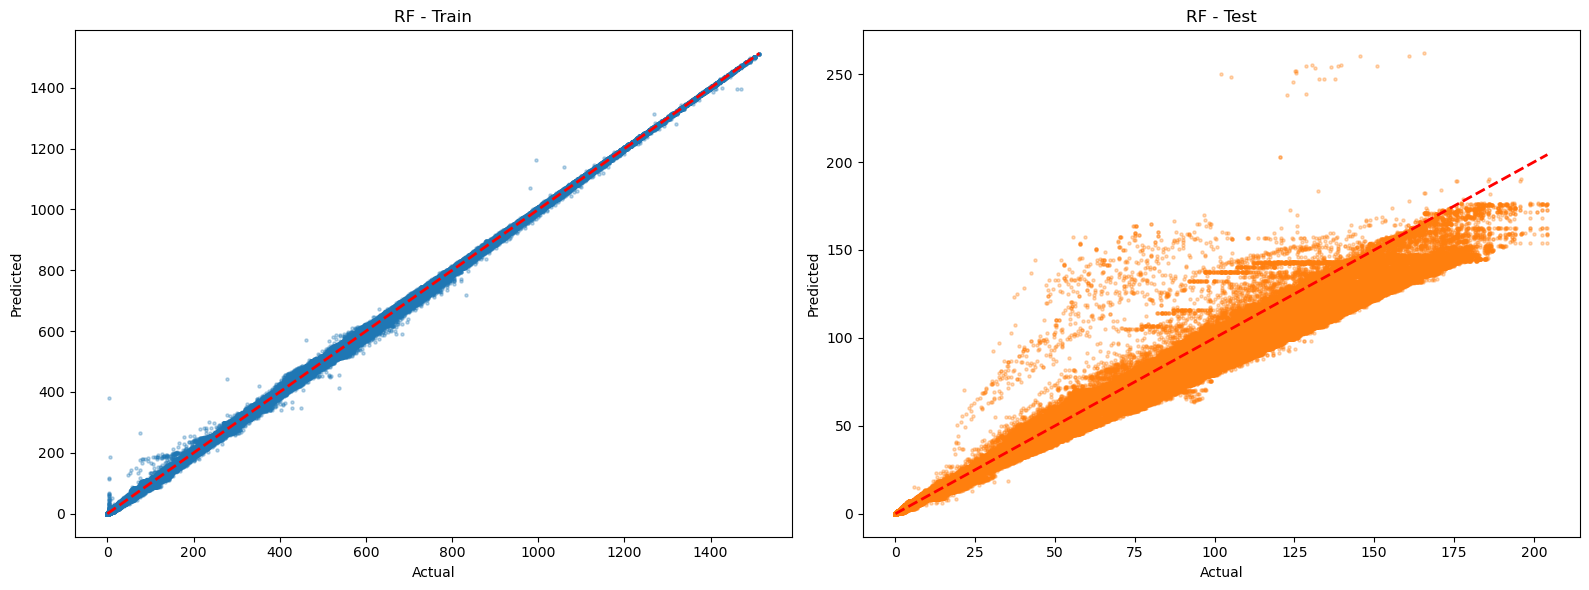

In [11]:
# Predicted vs Actual
fig,axes=plt.subplots(1,2,figsize=(16,6))
for ax,yt,yp,t,c in [(axes[0],y_train,y_pred_tr,'Train','tab:blue'),
                      (axes[1],y_test,y_pred_te,'Test','tab:orange')]:
    ax.scatter(yt,yp,alpha=.3,s=5,c=c)
    ax.plot([yt.min(),yt.max()],[yt.min(),yt.max()],'r--',lw=2)
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted'); ax.set_title(f'RF - {t}')
plt.tight_layout(); plt.show()

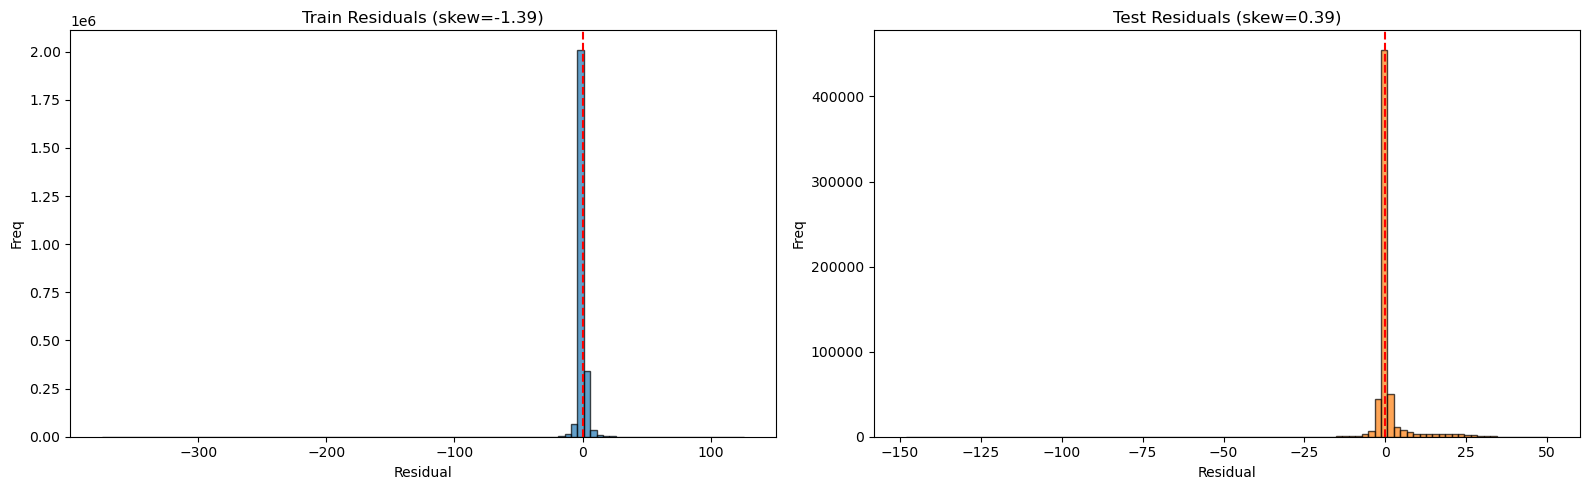

In [12]:
# Residual histograms
res_tr = y_train.values - y_pred_tr
res_te = y_test.values  - y_pred_te
fig,axes=plt.subplots(1,2,figsize=(16,5))
for ax,r,t,c in [(axes[0],res_tr,'Train','tab:blue'),(axes[1],res_te,'Test','tab:orange')]:
    ax.hist(r,bins=100,alpha=.7,color=c,edgecolor='black')
    ax.axvline(0,color='r',ls='--')
    ax.set_title(f'{t} Residuals (skew={stats.skew(r):.2f})')
    ax.set_xlabel('Residual'); ax.set_ylabel('Freq')
plt.tight_layout(); plt.show()

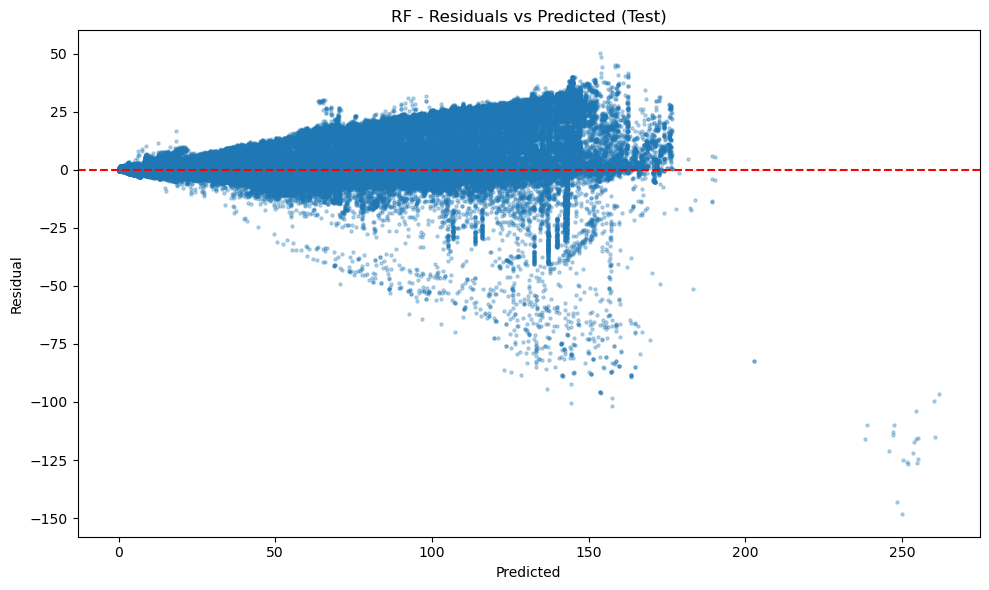

In [13]:
# Residuals vs Predicted
plt.figure(figsize=(10,6))
plt.scatter(y_pred_te, res_te, alpha=.3, s=5)
plt.axhline(0, color='r', ls='--')
plt.xlabel('Predicted'); plt.ylabel('Residual')
plt.title('RF - Residuals vs Predicted (Test)'); plt.tight_layout(); plt.show()

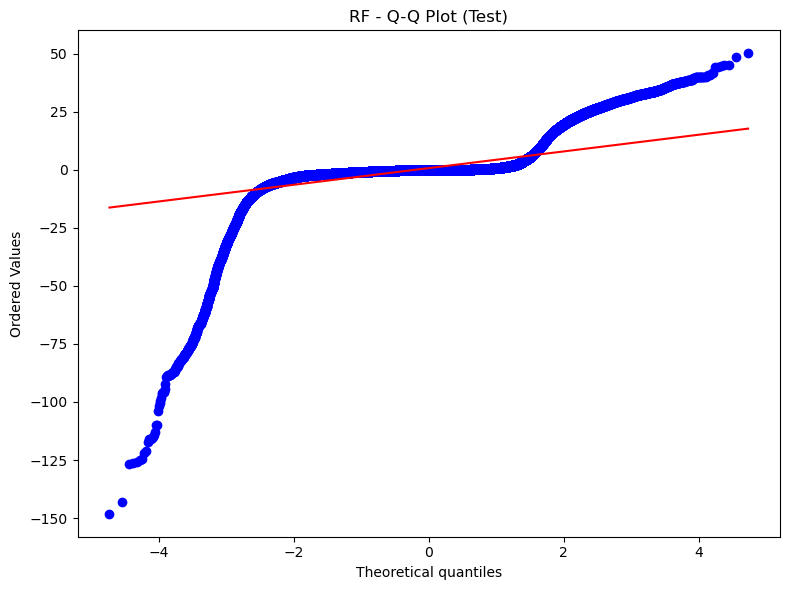

In [14]:
# Q-Q plot
fig,ax=plt.subplots(figsize=(8,6))
stats.probplot(res_te, dist='norm', plot=ax)
ax.set_title('RF - Q-Q Plot (Test)'); plt.tight_layout(); plt.show()

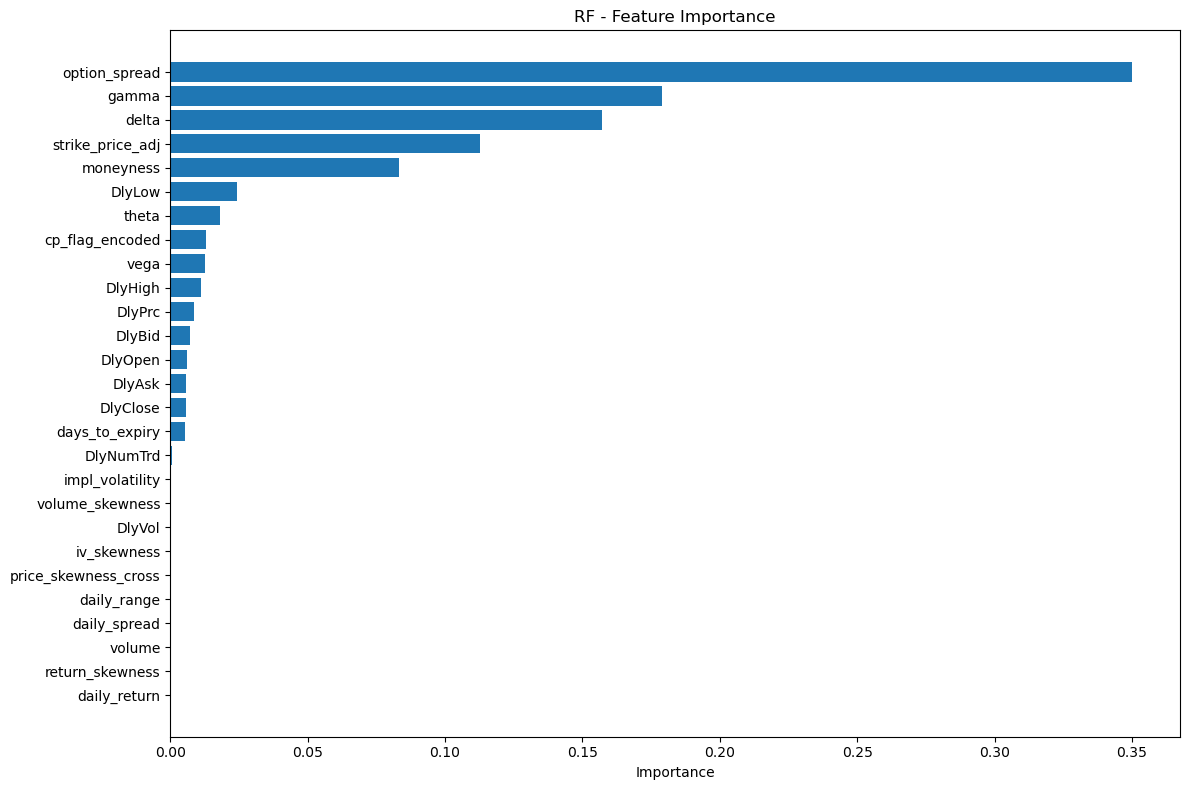

In [15]:
# Feature importance (built-in)
imp = pd.DataFrame({'Feature': num_features, 'Importance': model.feature_importances_})
imp = imp.sort_values('Importance', ascending=True)
plt.figure(figsize=(12,8))
plt.barh(imp['Feature'], imp['Importance'])
plt.xlabel('Importance'); plt.title('RF - Feature Importance')
plt.tight_layout(); plt.show()

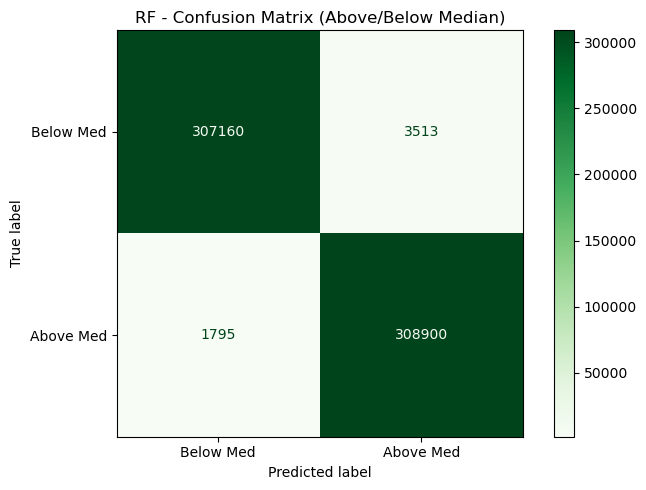

              precision    recall  f1-score   support

   Below Med       0.99      0.99      0.99    310673
   Above Med       0.99      0.99      0.99    310695

    accuracy                           0.99    621368
   macro avg       0.99      0.99      0.99    621368
weighted avg       0.99      0.99      0.99    621368



In [16]:
# Confusion matrix (above / below median)
med = y_test.median()
yt_c = (y_test.values >= med).astype(int)
yp_c = (y_pred_te >= med).astype(int)
cm = confusion_matrix(yt_c, yp_c)
fig,ax=plt.subplots(figsize=(7,5))
ConfusionMatrixDisplay(cm, display_labels=['Below Med','Above Med']).plot(ax=ax,cmap='Greens')
ax.set_title('RF - Confusion Matrix (Above/Below Median)')
plt.tight_layout(); plt.show()
print(classification_report(yt_c, yp_c, target_names=['Below Med','Above Med']))

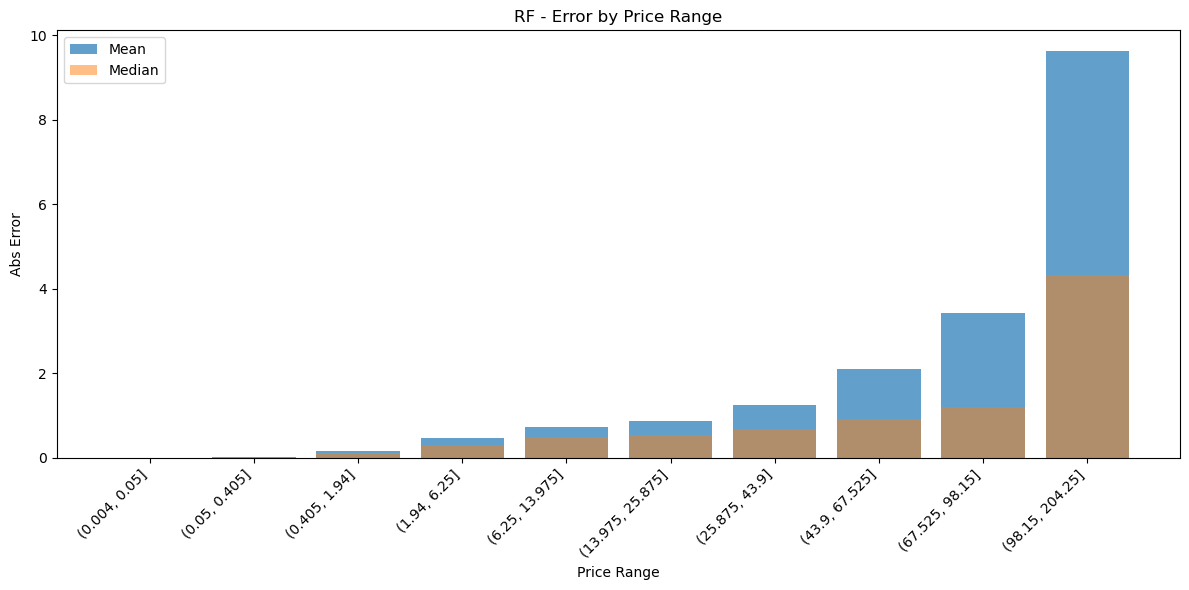

In [17]:
# Error by price bin
tr = pd.DataFrame({'actual':y_test.values,'predicted':y_pred_te,'abs_err':np.abs(res_te)})
tr['bin'] = pd.qcut(tr['actual'], q=10, duplicates='drop')
be = tr.groupby('bin')['abs_err'].agg(['mean','median']).reset_index()
plt.figure(figsize=(12,6))
x=range(len(be))
plt.bar(x, be['mean'], alpha=.7, label='Mean')
plt.bar(x, be['median'], alpha=.5, label='Median')
plt.xticks(x,[str(b) for b in be['bin']],rotation=45,ha='right')
plt.xlabel('Price Range'); plt.ylabel('Abs Error')
plt.title('RF - Error by Price Range'); plt.legend()
plt.tight_layout(); plt.show()

In [18]:
# OOB score (if available)
# Note: set oob_score=True in model to enable
# print(f'OOB Score: {model.oob_score_:.4f}')

In [19]:
# Summary table
summary = pd.DataFrame({'Set':['Train','Test'],
  'MSE':[tr_m['MSE'],te_m['MSE']],'RMSE':[tr_m['RMSE'],te_m['RMSE']],
  'MAE':[tr_m['MAE'],te_m['MAE']],'MAPE%':[tr_m['MAPE'],te_m['MAPE']],
  'R2':[tr_m['R2'],te_m['R2']],'EVS':[tr_m['EVS'],te_m['EVS']]})
print('\nRANDOM FOREST SUMMARY')
print(summary.to_string(index=False))


RANDOM FOREST SUMMARY
  Set       MSE     RMSE      MAE     MAPE%       R2      EVS
Train  6.758141 2.599643 1.214944  6.506405 0.999852 0.999852
 Test 28.557528 5.343924 1.866539 11.347827 0.983124 0.983504
